Импорт нужных библиотек

In [1]:
import os
import math
import time
import random
from typing import Dict, List, Tuple

import numpy as np
import matplotlib.pyplot as plt
import json
import pandas as pd
from pathlib import Path

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset

import torchvision
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

print("torch:", torch.__version__)
print("torchvision:", torchvision.__version__)

torch: 2.7.1+cu118
torchvision: 0.22.1+cu118


Фиксация seed и определение устройства

In [2]:
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

RANDOM_STATE = 42
set_seed(RANDOM_STATE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

FAST_MODE = True
DATA_DIR = "./data"

BATCH_SIZE = 64
EPOCHS = 3 if FAST_MODE else 8
EPOCHS_HEAD = 3 if FAST_MODE else 8
EPOCHS_FT   = 3 if FAST_MODE else 8

Device: cuda


Данные и DataLoader
Загрузка датасета STL10 и подготовка transforms
Берем веса для ResNet

In [3]:
def get_resnet18_weights():
    try:
        w = ResNet18_Weights.DEFAULT
        return w
    except Exception as e:
        print("Не удалось получить веса ResNet18_Weights.DEFAULT. Причина:", repr(e))
        return None

weights = get_resnet18_weights()
print("weights:", weights)

weights: ResNet18_Weights.IMAGENET1K_V1


базовый transform для CNN
transform с аугментациями
preprocessing для ResNet с pretrained weights

In [4]:
IMAGENET_MEAN = (0.485, 0.456, 0.406)
IMAGENET_STD  = (0.229, 0.224, 0.225)

IMG_SIZE = 224

def load_stl10(data_dir: str = DATA_DIR):
    train_tf = transforms.Compose([
        transforms.Resize(IMG_SIZE + 32),
        transforms.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    eval_tf = transforms.Compose([
        transforms.Resize(IMG_SIZE + 32),
        transforms.CenterCrop(IMG_SIZE),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

    ds_train_aug = torchvision.datasets.STL10(root=data_dir, split='train', download=True, transform=train_tf)
    ds_train_eval = torchvision.datasets.STL10(root=data_dir, split='train', download=True, transform=eval_tf)
    ds_test = torchvision.datasets.STL10(root=data_dir, split='test', download=True, transform=eval_tf)

    return ds_train_aug, ds_train_eval, ds_test

ds_train_aug, ds_train_eval, ds_test = load_stl10()
class_names = ds_train_aug.classes
print("Train full:", len(ds_train_aug))
print("Test:", len(ds_test))
print("Classes:", class_names)

100.0%


Train full: 5000
Test: 8000
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


DataLoader для train/val/test в части A

In [5]:
def make_loaders_tl(
    ds_train_aug,
    ds_train_eval,
    ds_test,
    batch_size: int = BATCH_SIZE,
    val_ratio: float = 0.2,
    seed: int = RANDOM_STATE,
    fast_mode: bool = FAST_MODE,
):
    n_total = len(ds_train_aug)
    n_val = int(n_total * val_ratio)

    rng = np.random.RandomState(seed)
    indices = np.arange(n_total)
    rng.shuffle(indices)

    val_idx = indices[:n_val]
    train_idx = indices[n_val:]

    ds_train = Subset(ds_train_aug, train_idx)
    ds_val   = Subset(ds_train_eval, val_idx)

    if fast_mode:
        train_idx2 = rng.choice(len(ds_train), size=min(4000, len(ds_train)), replace=False)
        val_idx2   = rng.choice(len(ds_val), size=min(1000, len(ds_val)), replace=False)
        test_idx2  = rng.choice(len(ds_test), size=min(1000, len(ds_test)), replace=False)

        ds_train = Subset(ds_train, train_idx2)
        ds_val   = Subset(ds_val, val_idx2)
        ds_test_small = Subset(ds_test, test_idx2)
    else:
        ds_test_small = ds_test

    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader   = DataLoader(ds_val, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader  = DataLoader(ds_test_small, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return train_loader, val_loader, test_loader

train_loader, val_loader, test_loader = make_loaders_tl(ds_train_aug, ds_train_eval, ds_test)
train_loader_c1, _, _ = make_loaders_tl(ds_train_eval, ds_train_eval, ds_test)

x, y = next(iter(train_loader))
print("x:", x.shape, x.dtype)
print("y:", y.shape, y.dtype)

x: torch.Size([64, 3, 224, 224]) torch.float32
y: torch.Size([64]) torch.int64


Загрузка датасета для части B
Загрузка датасета OxfordIIITPet для сегментации

In [6]:
img_transform = transforms.Compose([
    transforms.Resize((520, 520)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

target_transform = transforms.Compose([
    transforms.Resize((520, 520)),
])

ds_pet = torchvision.datasets.OxfordIIITPet(
    root="./data", split="trainval", download=True,
    transform=img_transform, target_transform=target_transform,
    target_types="segmentation"
)

print(f"Dataset size: {len(ds_pet)}")

100.0%
100.0%


Dataset size: 3680


sanity-check и примеры изображений для обеих частей
Часть A
Примеры картинок в датасете

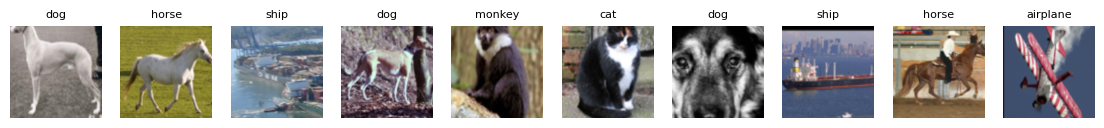

In [7]:
def denorm_cifar(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images(loader, n: int = 10) -> None:
    x, y = next(iter(loader))
    x = x[:n].cpu()
    y = y[:n].cpu()

    plt.figure(figsize=(14, 2))
    for i in range(n):
        plt.subplot(1, n, i + 1)
        img = denorm_cifar(x[i]).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(class_names[y[i].item()], fontsize=8)
        plt.axis("off")
    plt.show()

show_images(train_loader, n=10)

Смотрим на размерности

In [8]:
NUM_CLASSES = 10

def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

class SimpleCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 32x32 -> 32x32
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 32x32 -> 16x16

            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 16x16 -> 16x16
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 16x16 -> 8x8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),# 8x8 -> 8x8
            nn.ReLU(),
            nn.MaxPool2d(2),                             # 8x8 -> 4x4
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 256),
            nn.ReLU(),
            nn.Linear(256, num_classes),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.features(x)
        x = self.classifier(x)
        return x

cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
print(cnn)
print("Trainable params:", count_params(cnn))

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=10, bias=True)
  )
)
Trainable params: 25786186


Проводим sanity-check

In [9]:
with torch.no_grad():
    x0 = torch.randn(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    y0 = cnn(x0)
print("Input:", x0.shape, "Output logits:", y0.shape)

Input: torch.Size([2, 3, 224, 224]) Output logits: torch.Size([2, 10])


Часть B
Вывод на предпросмотр картинок

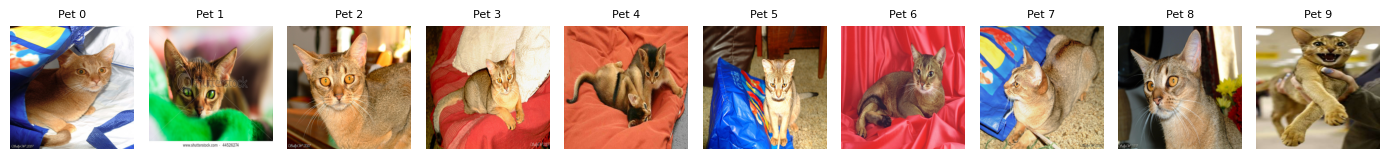

In [10]:
def denorm_img_b(x: torch.Tensor) -> torch.Tensor:
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return x * std + mean

@torch.no_grad()
def show_images_b(dataset, n: int = 10) -> None:
    plt.figure(figsize=(14, 2))
    for i in range(n):
        img, mask = dataset[i]
        
        plt.subplot(1, n, i + 1)
        img = denorm_img_b(img).clamp(0, 1).permute(1, 2, 0).numpy()
        plt.imshow(img)
        plt.title(f"Pet {i}", fontsize=8)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_images_b(ds_pet, n=10)

Обучение и оценка

In [11]:
def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return (preds == y_true).float().mean().item()

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)

        optimizer.zero_grad(set_to_none=True)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        loss.backward()
        optimizer.step()

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss, total_correct, total_seen = 0.0, 0, 0

    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        loss = criterion(logits, y)

        if not torch.isfinite(loss):
            return float("nan"), float("nan")

        bs = y.size(0)
        total_loss += loss.item() * bs
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += bs

    return total_loss / total_seen, total_correct / total_seen

def fit(model, train_loader, val_loader, optimizer, criterion, epochs: int = 5, verbose: bool = True):
    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

    for epoch in range(1, epochs + 1):
        t0 = time.time()
        tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, criterion)
        va_loss, va_acc = evaluate(model, val_loader, criterion)

        history["train_loss"].append(tr_loss)
        history["train_acc"].append(tr_acc)
        history["val_loss"].append(va_loss)
        history["val_acc"].append(va_acc)

        dt = time.time() - t0
        if verbose:
            print(
                f"Epoch {epoch:02d}/{epochs} | "
                f"train loss {tr_loss:.4f}, acc {tr_acc:.3f} | "
                f"val loss {va_loss:.4f}, acc {va_acc:.3f} | {dt:.1f}s"
            )

        if (not math.isfinite(tr_loss)) or (not math.isfinite(va_loss)):
            print("NaN/Inf в loss – обычно это признак проблем с LR/стабильностью. Останавливаем обучение.")
            break

    return history

def plot_history(hist: Dict[str, List[float]], title: str = "") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_loss"], label="train loss")
    plt.plot(epochs, hist["val_loss"], label="val loss")
    plt.xlabel("epoch")
    plt.ylabel("loss")
    plt.title(title + " | loss")
    plt.grid(True)
    plt.legend()
    plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.show()

def plot_history_save_best(hist: Dict[str, List[float]], title: str = "", save_title: str = "classification_curves_best") -> None:
    epochs = list(range(1, len(hist["train_loss"]) + 1))

    plt.figure(figsize=(10, 4))
    plt.plot(epochs, hist["train_acc"], label="train acc")
    plt.plot(epochs, hist["val_acc"], label="val acc")
    plt.xlabel("epoch")
    plt.ylabel("accuracy")
    plt.title(title + " | accuracy")
    plt.grid(True)
    plt.legend()
    plt.savefig(f"./artifacts/figures/{save_title}.png")
    print(f"График сохранён: ./artifacts/figures/{save_title}.png")

def plot_history_save_compare(results, titles, title: str = "", save_title: str = "classification_compare") -> None:
    best_accs = [float(np.nanmax(h["val_acc"])) if len(h["val_acc"]) > 0 else 0.0 for h in results]
    
    plt.figure(figsize=(10, 7))
    
    bars = plt.bar(titles, best_accs, edgecolor="black")

    for bar, acc in zip(bars, best_accs):
        plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
                 f"{acc:.3f}", ha="center", va="bottom", fontsize=10)
    
    plt.xlabel("experiment")
    plt.ylabel("beat val accuracy")
    plt.title(title + " | accuracy")
    plt.legend()
    plt.savefig(f"./artifacts/figures/{save_title}.png")
    print(f"График сохранён: ./artifacts/figures/{save_title}.png")

C1


Experiment C1_simple_cnn_base | lr=0.001 weight_decay=0.0 epochs=3
Trainable params: 25786186
Epoch 01/3 | train loss 2.0099, acc 0.283 | val loss 1.7035, acc 0.384 | 32.1s
Epoch 02/3 | train loss 1.4805, acc 0.465 | val loss 1.4873, acc 0.462 | 31.3s
Epoch 03/3 | train loss 1.2130, acc 0.562 | val loss 1.4603, acc 0.477 | 29.8s


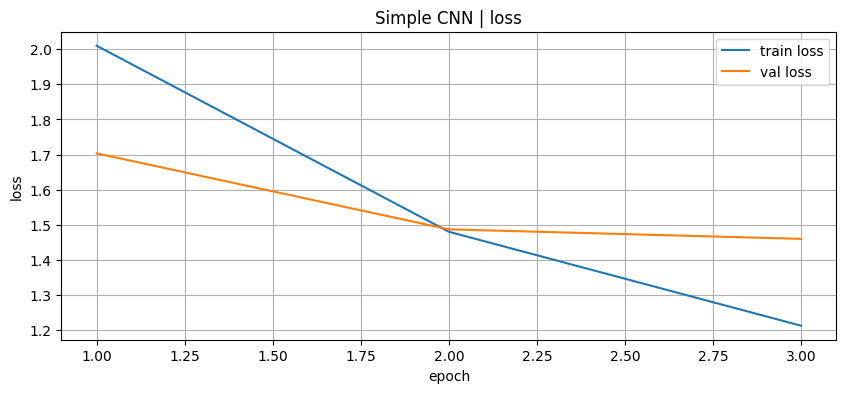

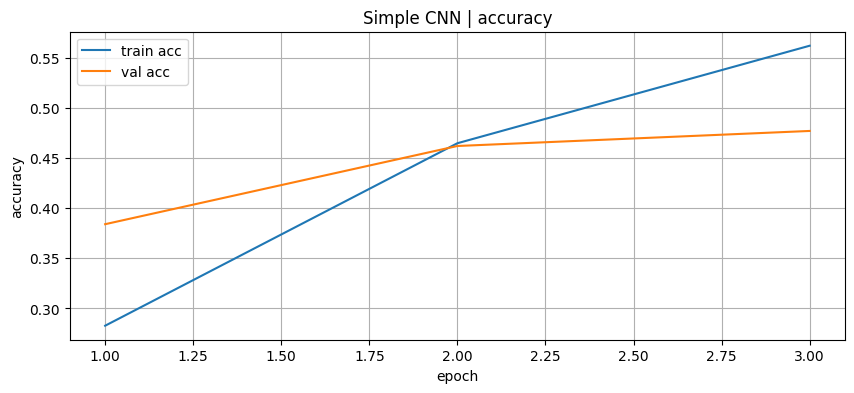

In [15]:
criterion = nn.CrossEntropyLoss()

def run_experiment(exp_id: str, model: nn.Module, train_loader, val_loader, lr: float = 1e-3, weight_decay: float = 0.0, epochs: int = EPOCHS):
    model = model.to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    print("\n" + "=" * 80)
    print(f"Experiment {exp_id} | lr={lr} weight_decay={weight_decay} epochs={epochs}")
    print("Trainable params:", count_params(model))

    hist = fit(model, train_loader, val_loader, optimizer, criterion, epochs=epochs, verbose=True)
    best_val_acc = float(np.nanmax(hist["val_acc"])) if len(hist["val_acc"]) else float("nan")

    return {"exp_id": exp_id, "model": model, "history": hist, "best_val_acc": best_val_acc}
res_c1 = run_experiment("C1_simple_cnn_base", SimpleCNN(NUM_CLASSES), train_loader_c1, val_loader, lr=1e-3, epochs=EPOCHS)
plot_history(res_c1["history"], title="Simple CNN")

C2


Experiment C2_simple_cnn_aug | lr=0.001 weight_decay=0.0 epochs=3
Trainable params: 25786186
Epoch 01/3 | train loss 2.1648, acc 0.229 | val loss 1.8271, acc 0.329 | 36.1s
Epoch 02/3 | train loss 1.6776, acc 0.378 | val loss 1.5789, acc 0.406 | 36.7s
Epoch 03/3 | train loss 1.5714, acc 0.424 | val loss 1.4733, acc 0.467 | 35.4s


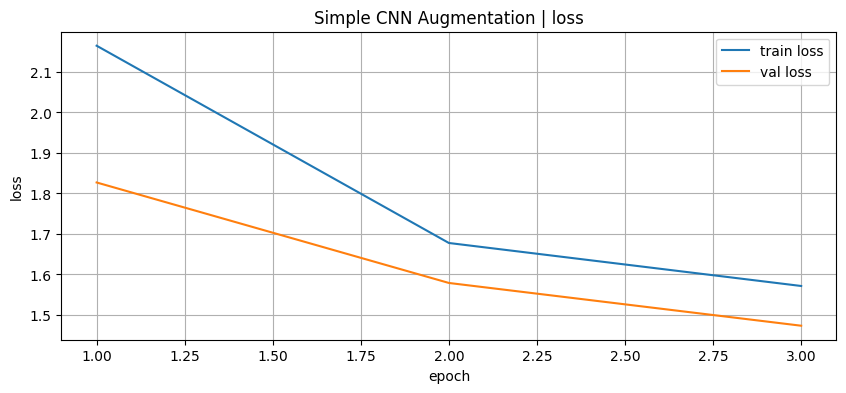

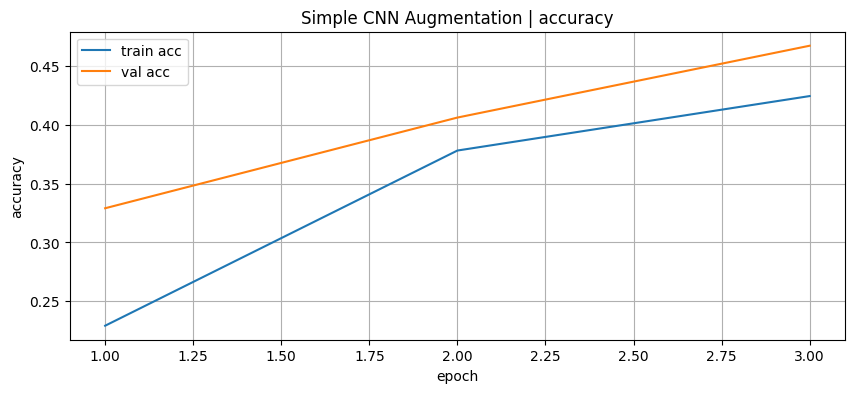

In [16]:
res_c2 = run_experiment("C2_simple_cnn_aug", SimpleCNN(NUM_CLASSES), train_loader, val_loader, lr=1e-3, epochs=EPOCHS)
plot_history(res_c2["history"], title="Simple CNN Augmentation")

ResNet18
Что дают аугментации:

помогают бороться с переобучением, так как они расширяют датасет, заставляя модель учить более различные признаки
учат модель распознавать объекты, даже если они смещены от центра или занимают лишь часть изображения
позволяют корректно классифицировать объекты, смотрящие в любую сторону

In [17]:
def count_trainable_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def build_resnet18(num_classes: int = 10, weights=weights) -> nn.Module:
    try:
        model = resnet18(weights=weights)
    except Exception as e:
        print("Не удалось загрузить предобученные веса. Переходим на weights=None. Причина:", repr(e))
        model = resnet18(weights=None)

    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model

def set_requires_grad(module: nn.Module, flag: bool) -> None:
    for p in module.parameters():
        p.requires_grad = flag

model = build_resnet18(num_classes=10, weights=weights).to(DEVICE)
print(model)
print("Trainable params:", count_trainable_params(model))

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

C3

Trainable params (head-only): 5130

Head-only training
Epoch 01/3 | train loss 1.0773, acc 0.723 | val loss 0.4813, acc 0.899 | 33.2s
Epoch 02/3 | train loss 0.3978, acc 0.914 | val loss 0.3165, acc 0.912 | 34.9s
Epoch 03/3 | train loss 0.2962, acc 0.931 | val loss 0.2705, acc 0.922 | 38.1s


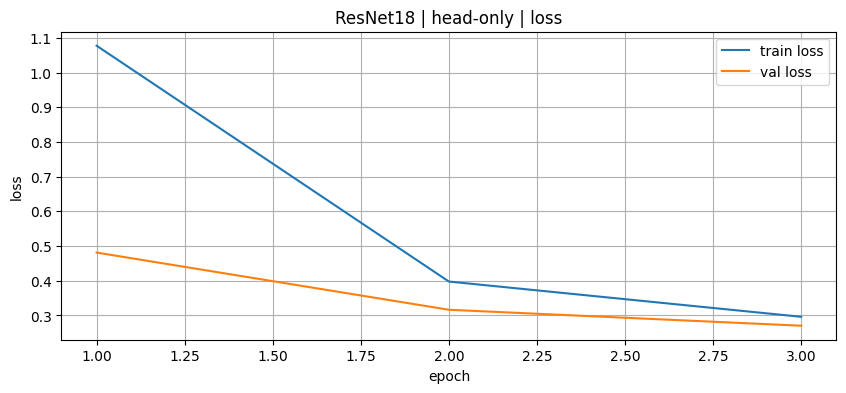

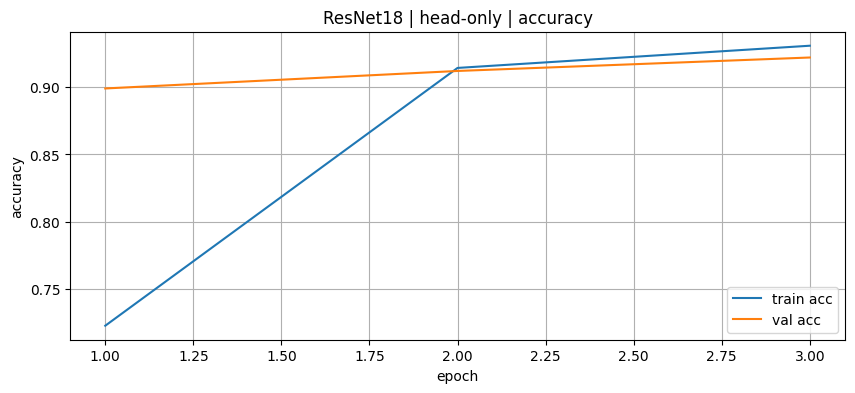

In [18]:
model_head = build_resnet18(num_classes=10, weights=weights).to(DEVICE)

set_requires_grad(model_head, False)
set_requires_grad(model_head.fc, True)

print("Trainable params (head-only):", count_trainable_params(model_head))

optimizer_head = torch.optim.Adam(model_head.fc.parameters(), lr=1e-3)

print("\n" + "=" * 80)
print("Head-only training")
hist_head = fit(model_head, train_loader, val_loader, optimizer_head, criterion, epochs=EPOCHS_HEAD, verbose=True)
plot_history(hist_head, title="ResNet18 | head-only")

C4

Trainable params (layer4+fc): 11181642

Fine-tuning layer4 + fc
Epoch 01/3 | train loss 0.5061, acc 0.853 | val loss 0.1847, acc 0.935 | 35.4s
Epoch 02/3 | train loss 0.1364, acc 0.961 | val loss 0.1632, acc 0.945 | 36.5s
Epoch 03/3 | train loss 0.0758, acc 0.980 | val loss 0.1605, acc 0.944 | 37.2s


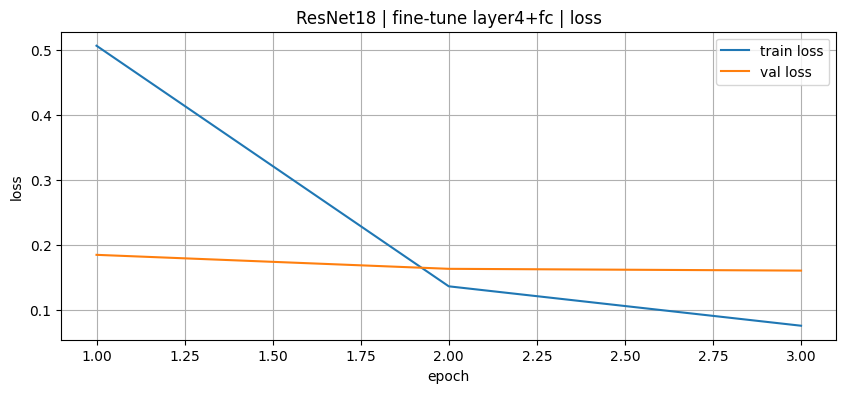

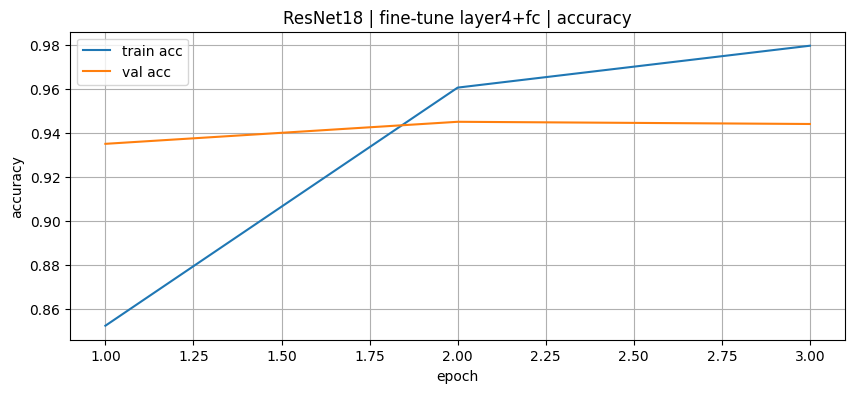

In [19]:
model_head_c4 = build_resnet18(num_classes=10, weights=weights).to(DEVICE)
set_requires_grad(model_head_c4.layer4, True)
set_requires_grad(model_head_c4.fc, True)

print("Trainable params (layer4+fc):", count_trainable_params(model_head_c4))

params = [
    {"params": model_head_c4.layer4.parameters(), "lr": 1e-4},
    {"params": model_head_c4.fc.parameters(), "lr": 1e-3},
]

optimizer_ft = torch.optim.Adam(params, weight_decay=1e-4)

print("\n" + "=" * 80)
print("Fine-tuning layer4 + fc")
hist_ft = fit(model_head_c4, train_loader, val_loader, optimizer_ft, criterion, epochs=EPOCHS_FT, verbose=True)
plot_history(hist_ft, title="ResNet18 | fine-tune layer4+fc")

In [20]:
@torch.no_grad()
def accuracy_on_loader(model, loader) -> float:
    model.eval()
    total_correct, total_seen = 0, 0
    for x, y in loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        logits = model(x)
        total_correct += (torch.argmax(logits, dim=1) == y).sum().item()
        total_seen += y.size(0)
    return total_correct / total_seen

Partial fine-tuning относительно head-only дал:

возможность адаптации признаков, так как дообучение layer4, отвечающий за признаки высокого уровня, позволяет адаптировать модель под специфику датасета
возможность тонко настраивать веса за счет меньшего lr у layer4, в то время как больший lr у fc обеспечивает быстрое обучение классификатора
Лучшая модель C4

Проводим тестирование

In [21]:
test_acc_c4 = accuracy_on_loader(model_head_c4, test_loader)
print("Test acc (C4):", round(test_acc_c4, 4))

Test acc (C4): 0.958


Сегментация
Установка модели DeepLabV3

In [22]:
import torchvision
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

weights = DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1
model = deeplabv3_resnet50(weights=weights)
model.to(DEVICE)
model.eval()

categories = weights.meta.get("categories", None)
if categories is None:
    raise RuntimeError("В weights.meta нет списка categories – сложно найти индекс 'cat' динамически.")

if "cat" not in categories:
    raise RuntimeError("В categories нет класса 'cat'. Проверьте, какие веса вы загрузили.")

CAT_IDX = categories.index("cat")
print("num_classes:", len(categories))
print("CAT_IDX:", CAT_IDX)

preprocess = weights.transforms()
preprocess

0.1%

Downloading: "https://download.pytorch.org/models/deeplabv3_resnet50_coco-cd0a2569.pth" to C:\Users\Awesome/.cache\torch\hub\checkpoints\deeplabv3_resnet50_coco-cd0a2569.pth


100.0%


num_classes: 21
CAT_IDX: 8


SemanticSegmentation(
    resize_size=[520]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)

In [23]:
with torch.no_grad():
    img, mask = ds_pet[0]
    x = img.unsqueeze(0).to(DEVICE)
    out = model(x)["out"]
    pred = out.argmax(1)

print(f"Input: {x.shape} Output logits: {pred.shape}")

Input: torch.Size([1, 3, 520, 520]) Output logits: torch.Size([1, 520, 520])


In [24]:
from PIL import Image
from dataclasses import dataclass
@dataclass
class RunConfig:
    data_dir: str = "./data"
    fast_mode: bool = True
    n_show: int = 3
    cat_only: bool = True

cfg = RunConfig()
cfg

RunConfig(data_dir='./data', fast_mode=True, n_show=3, cat_only=True)

In [25]:
from torchvision.transforms import functional as F
from torchvision.transforms import InterpolationMode

@torch.no_grad()
def predict_cat_mask(img_pil: Image.Image, mode="V1", threshold: float = 0.3) -> torch.Tensor:
    x = preprocess(img_pil).unsqueeze(0).to(DEVICE)
    out = model(x)["out"][0]

    if mode == "V1":
        pred = out.argmax(0)
        cat = (pred == int(CAT_IDX)).to(torch.uint8)
    else:
        probs = torch.softmax(out, dim=0)
        cat_prob = probs[CAT_IDX]
        cat = (cat_prob > threshold).to(torch.uint8)

    return cat.cpu(), x.shape[-2:]

def iou_binary(pred: torch.Tensor, gt: torch.Tensor) -> float:
    pred = pred.bool()
    gt = gt.bool()
    inter = (pred & gt).sum().item()
    union = (pred | gt).sum().item()
    return float(inter / (union + 1e-9))

def pixel_metrics(pred: torch.Tensor, gt: torch.Tensor) -> tuple:
    """Precision и Recall на уровне пикселей"""
    pred = pred.bool()
    gt = gt.bool()
    tp = (pred & gt).sum().item()
    fp = (pred & ~gt).sum().item()
    fn = (~pred & gt).sum().item()
    precision = tp / (tp + fp + 1e-9)
    recall = tp / (tp + fn + 1e-9)
    return precision, recall

def eval_subset(indices: List[int], mode="V1", threshold: float = 0.3) -> Dict[str, float]:
    ious, precisions, recalls = [], [], []
    for idx in indices:
        img_tensor, gt_mask_pil = ds_pet[idx]

        img_denorm = img_tensor * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + \
                     torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
        img_pil = transforms.ToPILImage()(img_denorm.clamp(0, 1))
        
        pred_mask, (h, w) = predict_cat_mask(img_pil, mode=mode, threshold=threshold)
        
        gt_np = np.array(gt_mask_pil)
        gt_binary = (gt_np > 0).astype(np.uint8)
        gt_pil = Image.fromarray((gt_binary * 255).astype(np.uint8))
        gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
        gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)

        ious.append(iou_binary(pred_mask, gt_mask))
        p, r = pixel_metrics(pred_mask, gt_mask)
        precisions.append(p)
        recalls.append(r)

    return {
        "n": float(len(ious)),
        "mean_IoU": float(np.mean(ious)),
        "median_IoU": float(np.median(ious)),
        "min_IoU": float(np.min(ious)),
        "max_IoU": float(np.max(ious)),
        "pixel_precision": float(np.mean(precisions)),
        "pixel_recall": float(np.mean(recalls)),
    }

if cfg.fast_mode:
    eval_indices = list(range(min(20, len(ds_pet))))
else:
    eval_indices = list(range(len(ds_pet)))

V1 - базовая постобработка маски

In [26]:
metrics_v1 = eval_subset(eval_indices, mode="V1")
metrics_v1

{'n': 20.0,
 'mean_IoU': 0.32707895710059054,
 'median_IoU': 0.29406065088757294,
 'min_IoU': 0.09219674556212984,
 'max_IoU': 0.5900147928994062,
 'pixel_precision': 0.9999999999999861,
 'pixel_recall': 0.32707895710059054}

V2 - альтернативная постобработка маски (порог для бинаризации foreground-класса = 0.3)

In [27]:
metrics_v2 = eval_subset(eval_indices, mode="V2")
metrics_v2

{'n': 20.0,
 'mean_IoU': 0.35054271449704016,
 'median_IoU': 0.33458764792899287,
 'min_IoU': 0.11058801775147889,
 'max_IoU': 0.6214829881656782,
 'pixel_precision': 0.9999999999999872,
 'pixel_recall': 0.35054271449704016}

График сохранён: figures/segmentation_examples.png


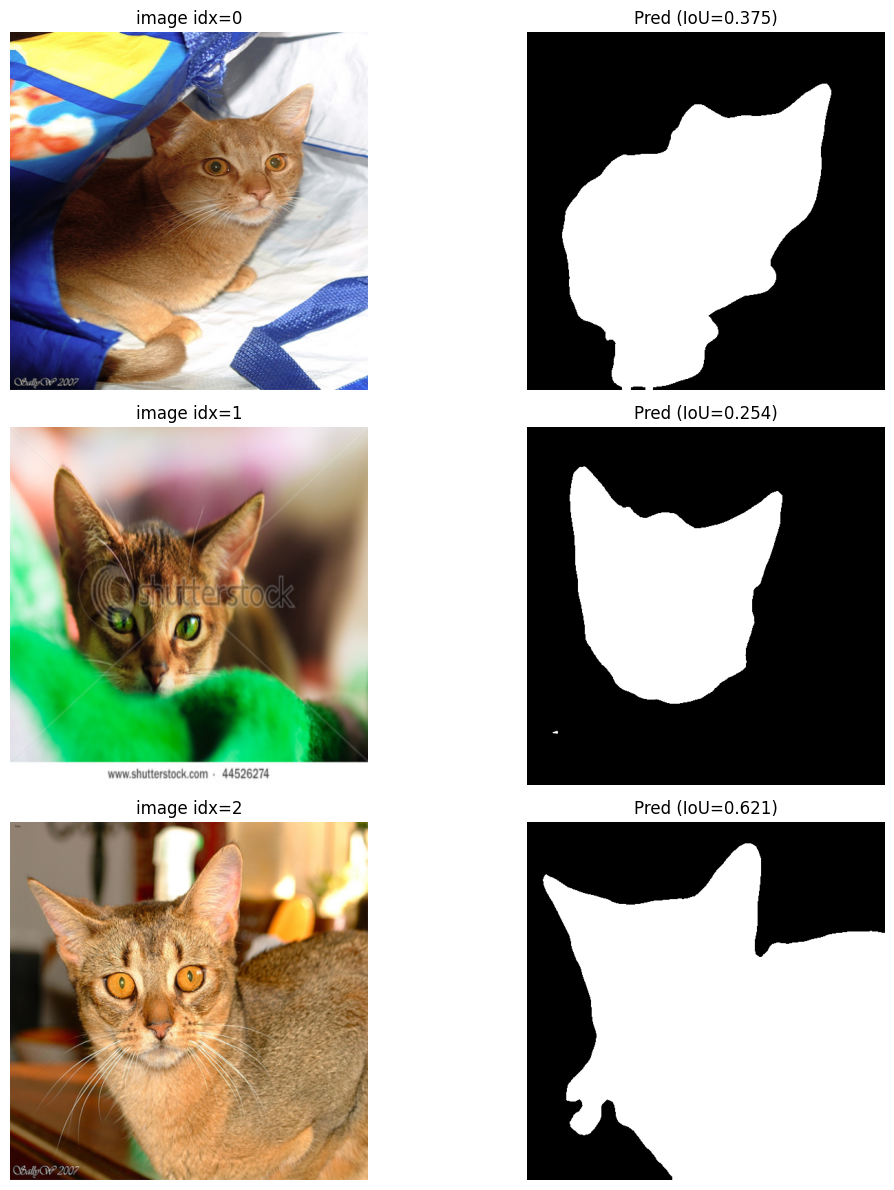

In [28]:
from torchvision.transforms import functional as F
from torchvision.transforms import InterpolationMode

n = min(cfg.n_show, len(ds_pet))
fig, axes = plt.subplots(n, 2, figsize=(12, 4*n))

if n == 1:
    axes = np.expand_dims(axes, axis=0)

for row in range(n):
    img_tensor, gt_mask_pil = ds_pet[row]

    img_denorm = img_tensor * torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1) + \
                 torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    img_pil = transforms.ToPILImage()(img_denorm.clamp(0, 1))
    
    pred_mask, (h, w) = predict_cat_mask(img_pil, mode="V2")

    gt_np = np.array(gt_mask_pil)
    gt_binary = (gt_np > 0).astype(np.uint8)
    gt_pil = Image.fromarray((gt_binary * 255).astype(np.uint8))
    gt_rs = F.resize(gt_pil, size=[h, w], interpolation=InterpolationMode.NEAREST)
    gt_mask = (torch.from_numpy(np.array(gt_rs)) > 0).to(torch.uint8)
    
    iou = iou_binary(pred_mask, gt_mask)

    img_np = img_denorm.clamp(0, 1).permute(1, 2, 0).numpy()
    
    axes[row, 0].imshow(img_np)
    axes[row, 0].set_title(f"image idx={row}")
    axes[row, 0].axis("off")

    #axes[row, 1].imshow(gt_mask.numpy(), cmap="gray")
    #axes[row, 1].set_title("GT (cat mask)")
    #axes[row, 1].axis("off")

    axes[row, 1].imshow(pred_mask.numpy(), cmap="gray")
    axes[row, 1].set_title(f"Pred (IoU={iou:.3f})")
    axes[row, 1].axis("off")

plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_examples.png", dpi=300, bbox_inches="tight")
print("График сохранён: figures/segmentation_examples.png")
plt.show()

Визуализация изображений и их предсказаний сохранена в файл segmentation_examples.png в папке artifacts/figures

В качестве foreground был выбран класс "cat" как наиболее понятный и воспроизводимый сценарий:

кошка - интуитивно понятный объект
модель DeepLabV3 предобучена на COCO (21 класс), где есть класс "cat", а в датасете OxfordIIITPet находится 37 пород кошек, но для наглядности берем также универсальный класс "cat"
бинарная задача по определению "кошка / не кошка" упрощает оценку и позволяет корректно посчитать метрики
В background вошли все остальные классы и фон

Сохранение артефактов

In [29]:
results = [
    {
        'experiment_id': 'C1',
        'task': 'classification',
        'dataset': 'STL10',
        'seed': 42,
        'model_summary': '32, 64, 128, 256 / ReLU / 0.0 / False',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'epochs_trained': 3,
        'best_val_accuracy': 0.469,
        'test_accuracy': None,
        'precision': None,
        'recall': None,
        'mean_iou': None,
        'notes': 'Базовая CNN без аугментаций'
    },
    {
        'experiment_id': 'C2',
        'task': 'classification',
        'dataset': 'STL10',
        'seed': 42,
        'model_summary': '32, 64, 128, 256 / ReLU / 0.0 / False',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'epochs_trained': 3,
        'best_val_accuracy': 0.461,
        'test_accuracy': None,
        'precision': None,
        'recall': None,
        'mean_iou': None,
        'notes': 'Базовая CNN с аугментацией'
    },
    {
        'experiment_id': 'C3',
        'task': 'classification',
        'dataset': 'STL10',
        'seed': 42,
        'model_summary': '32, 64, 128, 256 / ReLU / 0.0 / False',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'epochs_trained': 3,
        'best_val_accuracy': 0.922,
        'test_accuracy': None,
        'precision': None,
        'recall': None,
        'mean_iou': None,
        'notes': 'Pretrained ResNet18. Backbone заморожен, обучается только fc'
    },
    {
        'experiment_id': 'C4',
        'task': 'classification',
        'dataset': 'STL10',
        'seed': 42,
        'model_summary': '32, 64, 128, 256 / ReLU / 0.0 / False',
        'optimizer': 'Adam',
        'lr': 1e-3,
        'epochs_trained': 3,
        'best_val_accuracy': 0.945,
        'test_accuracy': 0.959,
        'precision': None,
        'recall': None,
        'mean_iou': None,
        'notes': 'Pretrained ResNet18. Разморожены layer4 + fc'
    },
    {
        'experiment_id': 'V1',
        'task': 'segmentation',
        'dataset': 'OxfordIIITPet',
        'seed': 42,
        'model_summary': 'DeepLabV3+ResNet50 / 21 classes / COCO pretrained',
        'optimizer': None,
        'lr': None,
        'epochs_trained': 0,
        'best_val_accuracy': None,
        'test_accuracy': None,
        'precision': 0.999,
        'recall': 0.327,
        'mean_iou': 0.327,
        'notes': 'Базовая постобработка для класса cat'
    },
    {
        'experiment_id': 'V2',
        'task': 'segmentation',
        'dataset': 'OxfordIIITPet',
        'seed': 42,
        'model_summary': 'DeepLabV3+ResNet50 / 21 classes / COCO pretrained',
        'optimizer': None,
        'lr': None,
        'epochs_trained': 0,
        'best_val_accuracy': None,
        'test_accuracy': None,
        'precision': 0.999,
        'recall': 0.350,
        'mean_iou': 0.350,
        'notes': 'Альтернативная постобработка маски (порог для бинаризации foreground-класса = 0.3)'
    },
]

df_runs = pd.DataFrame(results)

output_path = './artifacts/runs.csv'

df_runs.to_csv(output_path, index=False, encoding='utf-8')

Таблица результатов по всем экспериментам части A и части B сохранена в файл runs.csv в папке artifacts/

In [30]:
tmp_path = './artifacts/best_classifier.pt'
torch.save(model_head.state_dict(), tmp_path)

state_dict() лучшей модели части A сохранён в файл best_classifier.pt в папке artifacts/

In [31]:
def save_json(obj: dict, path: Path):
    path.parent.mkdir(parents=True, exist_ok=True)
    with path.open("w", encoding="utf-8") as f:
        json.dump(obj, f, ensure_ascii=False, indent=2)


ARTIFACTS_DIR = Path("artifacts")

best_config = {
    "experiment_id": "C4",
    "dataset": "STL10",
    "seed": 42,
    "model_type": "ResNet18",
    "num_classes": 10,
    "fine_tune_layers": ["layer4", "fc"],
    "model_summary": "32, 64, 128, 256 / ReLU / 0.0 / False",
    "optimizer": "Adam",
    "layer4_lr": 1e-4,
    "fc_lr": 1e-4,
    "batch_size": 64,
    "epochs": 3,
    "criterion": "CrossEntropyLoss",
    "best_val_accuracy": 0.945,
    "best_val_loss": 0.161,
    'test_accuracy': 0.959
}

save_json(best_config, ARTIFACTS_DIR / "best_classifier_config.json")

Конфиг лучшей модели части A сохранён в файл best_classifier_config.json в папке artifacts/

График сохранён: ./artifacts/figures/classification_curves_best.png


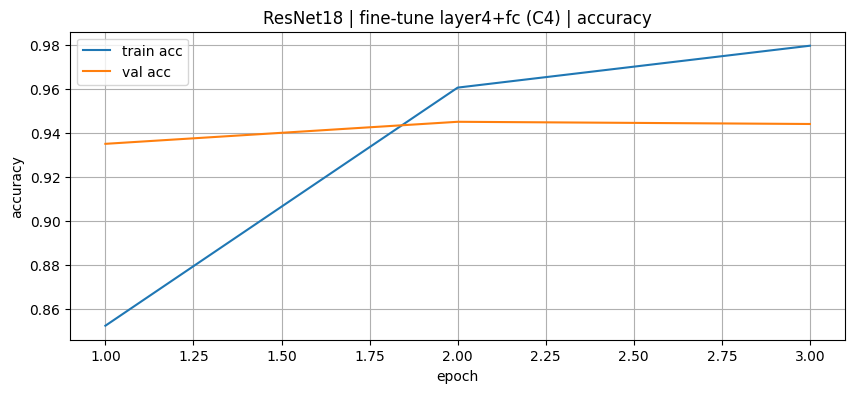

In [32]:
plot_history_save_best(hist_ft, title="ResNet18 | fine-tune layer4+fc (C4)", save_title="classification_curves_best")

График train/val accuracy для лучшего прогона классификации C3 сохранён в файл classification_curves_best.png в папке artifacts/figures

C:\Users\Awesome\AppData\Local\Temp\ipykernel_19968\1644179823.py:127: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


График сохранён: ./artifacts/figures/classification_compare.png


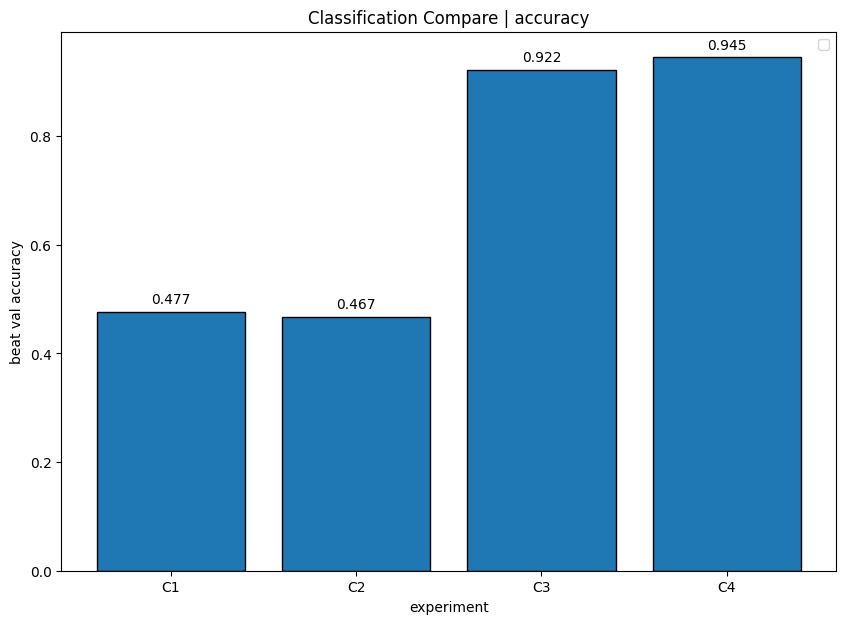

In [33]:
results_c = [res_c1["history"], res_c2["history"], hist_head, hist_ft]
titles = ['C1', 'C2', 'C3', 'C4']
plot_history_save_compare(results=results_c, titles=titles, title="Classification Compare", save_title="classification_compare")

Краткое сравнение C1-C4 сохранено в файл classification_compare.png в папке artifacts/figures

График сохранён: ./artifacts/figures/augmentations_preview.png


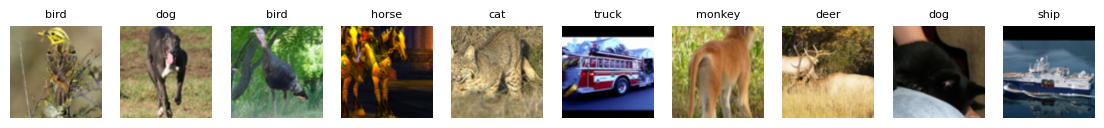

In [34]:
def show_images_save(dataset, n: int = 10, save_title: str = "augmentations_preview") -> None:
    plt.figure(figsize=(14, 2))
    for i in range(n):
        img, label = dataset[i]
        plt.subplot(1, n, i + 1)
        img = img * torch.tensor(IMAGENET_STD).view(3, 1, 1) + torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        plt.imshow(img.clamp(0, 1).permute(1, 2, 0))
        plt.title(class_names[label], fontsize=8)
        plt.axis("off")
    plt.savefig(f"./artifacts/figures/{save_title}.png")
    print(f"График сохранён: ./artifacts/figures/{save_title}.png")
    plt.show()

class_idx = class_names.index("cat")
show_images_save(ds_train_aug, n=10, save_title="augmentations_preview")

Визуализация аугментаций сохранена в файл augmentations_preview.png в папке artifacts/figures

График сохранён: artifacts/figures/segmentation_metrics.png


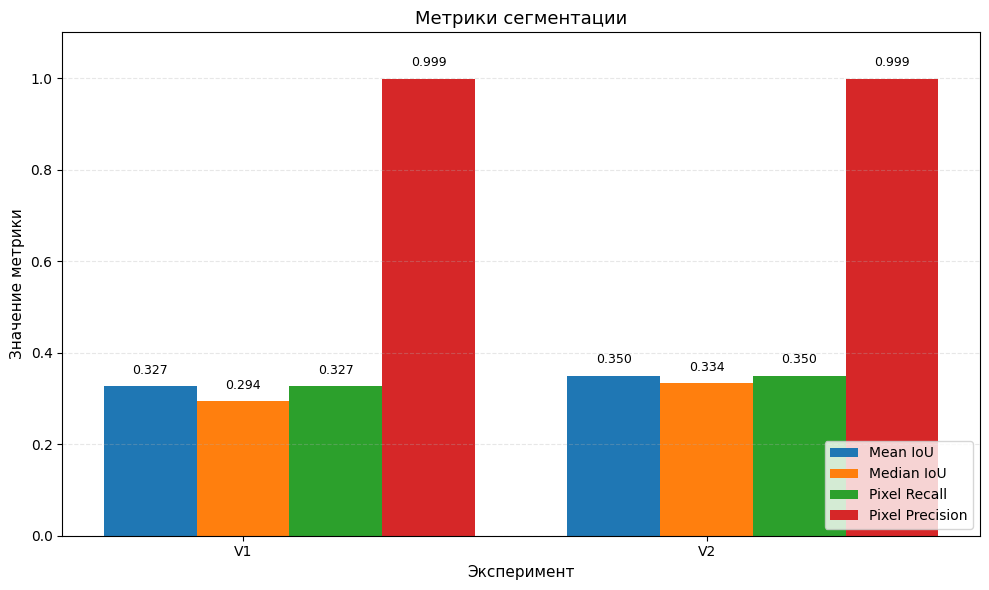

In [35]:
metrics = {
    "V1": {
        'mean_iou': 0.327,
        'median_iou': 0.294,
        'pixel_recall': 0.327,
        'pixel_precision': 0.999
    },
    "V2": {
        'mean_iou': 0.350,
        'median_iou': 0.334,
        'pixel_recall': 0.350,
        'pixel_precision': 0.999
    }
}

labels = list(metrics.keys())
mean_iou_vals = [metrics[l]["mean_iou"] for l in labels]
median_iou_vals = [metrics[l]["median_iou"] for l in labels]
rec_vals = [metrics[l]["pixel_recall"] for l in labels]
prec_vals = [metrics[l]["pixel_precision"] for l in labels]

x = np.arange(len(labels))
width = 0.2

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width, mean_iou_vals, width, label="Mean IoU")
bars2 = ax.bar(x, median_iou_vals, width, label="Median IoU")
bars3 = ax.bar(x + width, rec_vals, width, label="Pixel Recall")
bars4 = ax.bar(x + 2*width, prec_vals, width, label="Pixel Precision")

# Подписи значений на столбцах
for bars in [bars1, bars2, bars3, bars4]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 0.02, 
                f"{height:.3f}", ha="center", va="bottom", fontsize=9)

ax.set_xlabel("Эксперимент", fontsize=11)
ax.set_ylabel("Значение метрики", fontsize=11)
ax.set_title("Метрики сегментации", fontsize=13)
ax.set_xticks(x)
ax.set_xticklabels(labels, ha="center")
ax.set_ylim(0, 1.1)
ax.legend(loc="lower right")
ax.grid(axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.savefig("artifacts/figures/segmentation_metrics.png", dpi=300, bbox_inches="tight")
print("График сохранён: artifacts/figures/segmentation_metrics.png")
plt.show()

Визуализация метрик части B сохранена в файл segmentation_metrics.png в папке artifacts/figures